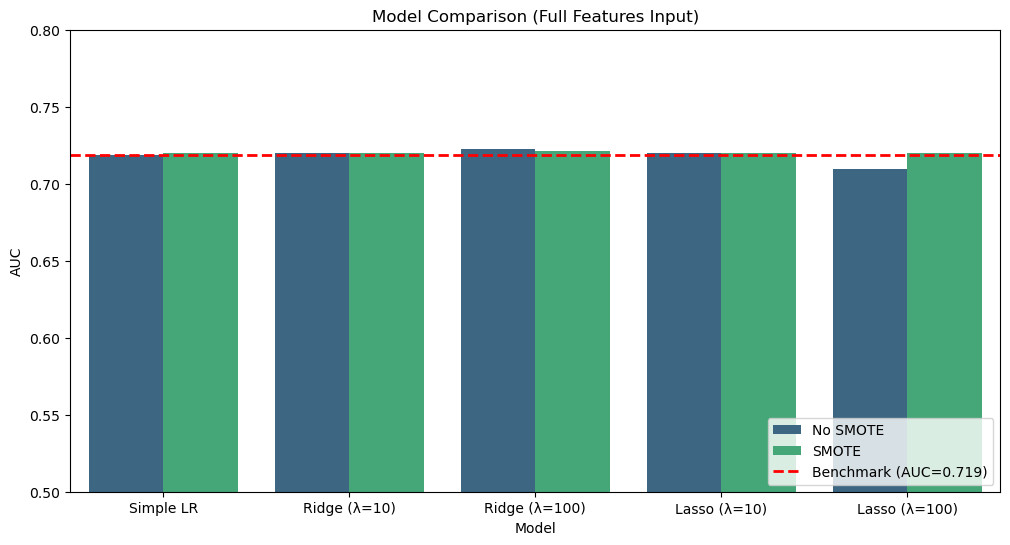


[Lasso Selected Features]


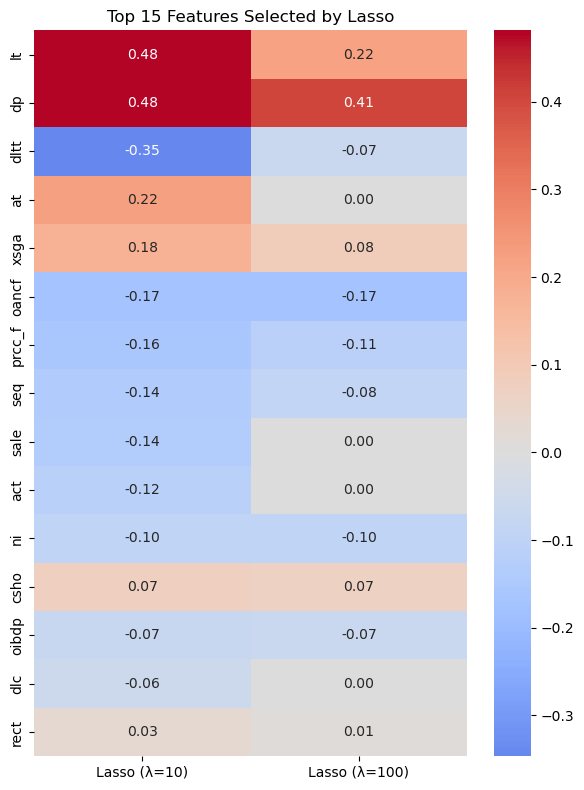

In [15]:
# 4_summary_results.ipynb
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = r"C:\Users\User-NB\OneDrive\Desktop\ML"
RESULT_DIR = os.path.join(BASE_DIR, "results")

# Load
bench = joblib.load(os.path.join(RESULT_DIR, "bench_results.pkl"))
res = joblib.load(os.path.join(RESULT_DIR, "research_results.pkl"))
df_res = res["results"]

# 1. AUC Comparison
plt.figure(figsize=(12, 6))
sns.barplot(data=df_res, x="Model", y="AUC", hue="Sampling", palette="viridis")
plt.axhline(y=bench['auc'], color='red', linestyle='--', linewidth=2, label=f'Benchmark (AUC={bench["auc"]:.3f})')
plt.ylim(0.5, 0.8)
plt.title("Model Comparison (Full Features Input)")
plt.legend(loc='lower right')
plt.savefig(os.path.join(RESULT_DIR, "final_auc.png"))
plt.show()

# 2. Lasso Selection Heatmap
print("\n[Lasso Selected Features]")
lasso_data = res["lasso_coefs"]
feats = res["feats"]

if lasso_data:
    df_lasso = pd.DataFrame(lasso_data, index=feats)
    # 排序：只顯示係數絕對值最大的前 15 個，避免圖太長
    df_lasso['abs_val'] = df_lasso.iloc[:,0].abs()
    df_lasso = df_lasso.sort_values(by='abs_val', ascending=False).drop(columns=['abs_val']).head(15)
    
    plt.figure(figsize=(6, 8))
    sns.heatmap(df_lasso, annot=True, cmap="coolwarm", center=0, fmt=".2f")
    plt.title("Top 15 Features Selected by Lasso")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, "lasso_selection.png"))
    plt.show()